# Piloting moving window size using a representative patient

Piloting for moving window size $S$ for Adaptive Window BT-LDA and piloting for optimal UC-pair for Adaptive CC BT-LDA

In [ ]:
import numpy as np
from BSc_Thesis_Project.ERP_analysis_code.patient_pipeline.hyperparameters.window_size.windowsize_functions import merge_all_data_of_patient, print_metadata_pilot, auc_datasizes_multisample


In [ ]:
# I have already run the code of this notebook so the results can be loaded with these two lines
sizes_medium_scores_6D = np.load('v2sizes_medium_scores_6D.npy')
sizes_medium = np.load('v2sizes_medium.npy')

# The data can be found in window_size/p9_ivals_0.1-0.81

In [ ]:
# The representative patient
patient = 9
last_online = 17
calibration_selection="6D_long_350"

# Collects all data used for this pilot
all_data, all_features = merge_all_data_of_patient(patient,last_online, calibration_selection)

print(print_metadata_pilot(all_data, all_features))

1


<function matplotlib.pyplot.show(close=None, block=None)>

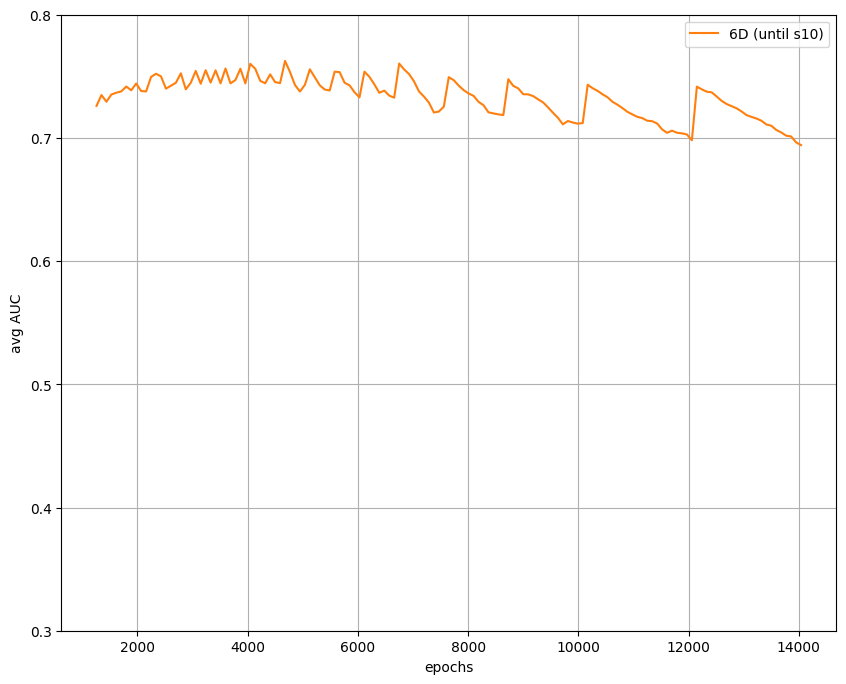

In [99]:
import matplotlib.pyplot as plt
print(len(sizes_medium_scores_6D[0:sizes_medium[-1]:600]))
plt.figure(figsize=(10,8))
plt.plot(sizes_medium,sizes_medium_scores_6D[0:len(sizes_medium)], label="6D (until s10)", color='tab:orange')
plt.ylim(0.3,0.8)
plt.grid()
#plt.xticks(sizes_medium)
plt.xlabel('epochs')
plt.ylabel('avg AUC')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

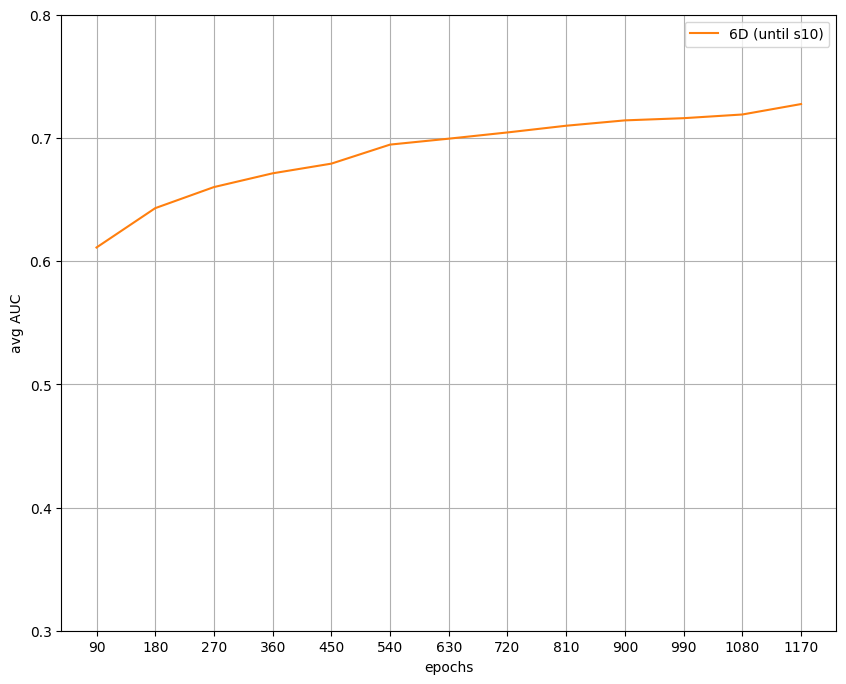

In [75]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.plot(sizes_small,sizes_small_scores_6D[:len(sizes_small)], label="6D (until s10)", color='tab:orange')
plt.ylim(0.3,0.8)
plt.grid()
plt.xticks(sizes_small)
plt.xlabel('epochs')
plt.ylabel('avg AUC')
plt.legend()
plt.show

In [ ]:
# Code used to obtain the results
sizes_medium = np.arange(1260,14100,90)
print(sizes_medium)
sizes_medium_scores_6D = auc_datasizes_multisample(all_data, all_features, sizes_medium, tracker=True)